## Lab 2: Generation of random number using pseudo Random and Chi-Square Test

# Name: Sanjiban Das
ACE080BCT68

### THEORY

Random Number:

A sequence of number chosen by-chance from a set of numbers.

* Condition:

1) Uniformly distributed value over a interval

2) impossible to detect based on past or present

* Random Variable:

-A random variable is a mathematical function that assigns a specific numerical value to each possible outcome of a random event or experiment.

* APPLICATION:

Cybersecurity

Machine Learning

Scientific Studies


### Algorithm for Generating Random/Number

* Linear Congruential Generator

The LCG is one of the oldest and best-known PRNG algorithms. It is computationally very fast and requires minimal memory, though it is not cryptographically secure and exhibits noticeable patterns in higher dimensions.

The Algorithm

The generator is defined by the recurrence relation:

$$X_{n+1} = (aX_n + c) \bmod m$$

Where:
$X$ is the sequence of pseudo-random values.
$X_0$ is the seed (starting value).
$m$ is the modulus ($m > 0$).
$a$ is the multiplier ($0 < a < m$).
$c$ is the increment ($0 \le c < m$).


* Mersenne Twister

The Mersenne Twister is the default PRNG in many modern programming languages (like Python, Ruby, and R). It has a massive period of $2^{19937} - 1$ and excellent statistical properties, though it is still not cryptographically secure.

The Algorithm

The algorithm works by maintaining an array of $n$ state words (usually 624 words of 32 bits each). It operates in three main steps:

1) Initialization: Seed the state array using a simple LCG-like formula.

2) Twisting: When all values in the array are consumed, a "twist" operation mixes the bits to generate a new block of 624 values.

3) Tempering: Extract a value from the array and pass it through a bit-shifting and masking filter to improve its statistical randomness.


* XOR shift Generator

Developed by George Marsaglia, XORshift is a class of PRNGs that are incredibly fast because they rely exclusively on exclusive OR (^) and bitwise shift (<<, >>) operations. They have small memory footprints and surprisingly good statistical properties for their simplicity.

The Algorithm

A standard 32-bit XORshift algorithm keeps a single 32-bit state variable and transforms it using a specific triplet of shift constants (e.g., 13, 17, 5).The mathematical step is:

1) $x \leftarrow x \oplus (x \ll a)$

2) $x \leftarrow x \oplus (x \gg b)$

3) $x \leftarrow x \oplus (x \ll c)$

### why chi square test is used in random number evaluation ?

--> In random number evaluation, the Chi-Square ($\chi^2$) Goodness-of-Fit test is used to determine whether a sequence of generated numbers is truly random or if it suffers from underlying bias.

#### The Formula

The test calculates a statistic ($\chi^2$) using the following formula:

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

Where:

$O_i$ = The Observed count of numbers in a specific category (or "bin").

$E_i$ = The Expected count of numbers in that category if the generator is uniform.


--> If the generator is good, the difference between Observed and Expected ($O_i - E_i$) will be very small, resulting in a low $\chi^2$ value. If the generator is biased, the $\chi^2$ value will be large.


Values of r: [124, 49, 178, 79, 24, 221, 46, 91, 116, 73, 106, 39, 144, 117, 102, 179, 108, 97, 34, 255, 8, 13, 158, 11, 100, 121, 218, 215, 128, 165, 214, 99, 92, 145, 146, 175, 248, 61, 14, 187, 84, 169, 74, 135, 112, 213, 70, 19, 76, 193, 2, 95, 232, 109, 126, 107, 68, 217, 186, 55, 96, 5, 182, 195, 60, 241, 114, 15, 216, 157, 238, 27, 52, 9, 42, 231, 80, 53, 38, 115, 44, 33, 226, 191, 200, 205, 94, 203, 36, 57, 154, 151, 64, 101, 150, 35, 28, 81, 82, 111, 184, 253, 206, 123, 20, 105, 10, 71, 48, 149, 6, 211, 12, 129, 194, 31, 168, 45, 62, 43, 4, 153, 122, 247, 32, 197, 118, 131, 252, 177, 50, 207, 152, 93, 174, 219, 244, 201, 234, 167, 16, 245, 230, 51, 236, 225, 162, 127, 136, 141, 30, 139, 228, 249, 90, 87, 0, 37, 86, 227, 220, 17, 18, 47, 120, 189, 142, 59, 212, 41, 202, 7, 240, 85, 198, 147, 204, 65, 130, 223, 104, 237, 254, 235, 196, 89, 58, 183, 224, 133, 54, 67, 188, 113, 242, 143, 88, 29, 110, 155, 180, 137, 170, 103, 208, 181, 166, 243, 172, 161, 98, 63, 72, 77, 222, 75, 1

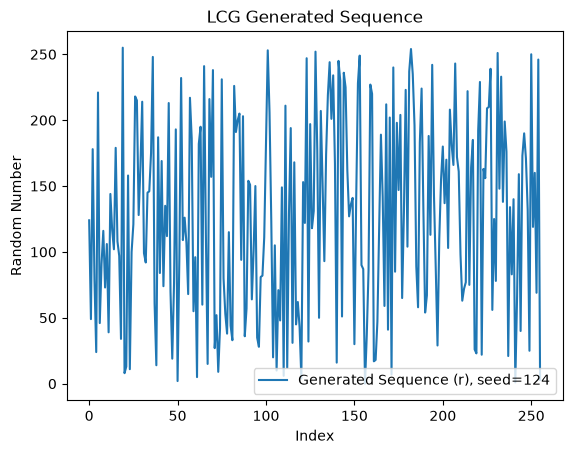

In [7]:
import matplotlib.pyplot as plt
import time

# ---------------- Constants ----------------
iterator = 256          # Number of random numbers to generate
a = 29                   # Multiplier
b = 37                   # Increment
p = 256                  # Modulus
n = 8                    # Number of bins for Chi-Square test
alpha = 0.05             # Significance level

# Chi-square critical value table (alpha = 0.05), standard textbook values
# indexed by degrees of freedom (df = n - 1)
chi2_table_005 = {
    1: 3.841, 2: 5.991, 3: 7.815, 4: 9.488, 5: 11.070,
    6: 12.592, 7: 14.067, 8: 15.507, 9: 16.919, 10: 18.307
}

df = n - 1
critical_value = chi2_table_005[df]
seed = int(time.time() * 1_000_000) % p

# ---------------- Generate LCG sequence ----------------
r = [0] * iterator
r[0] = seed  # seed / initial state, set manually (no random module involved)

for i in range(iterator - 1):
    r[i + 1] = (r[i] * a + b) % p

# ---------------- Bin the generated numbers ----------------
c = [0] * n
ei = iterator / n  # expected frequency per bin

for value in r:
    if value <= 31:
        c[0] += 1
    elif value <= 63:
        c[1] += 1
    elif value <= 95:
        c[2] += 1
    elif value <= 127:
        c[3] += 1
    elif value <= 159:
        c[4] += 1
    elif value <= 191:
        c[5] += 1
    elif value <= 223:
        c[6] += 1
    else:
        c[7] += 1

# ---------------- Chi-square statistic ----------------
x02 = 0
for i in range(n):
    x02 += ((c[i] - ei) ** 2) / ei

# ---------------- Results ----------------
print("Values of r:", r)
print("Bin frequencies (c):", c)
print("Chi-square statistic (x02):", x02)
print("Critical value (alpha=0.05, df={}):".format(df), critical_value)
print("Chi-square test passed" if x02 <= critical_value else "Chi-square test failed")

# ---------------- Visualization ----------------
plt.figure()
plt.plot(r, label="Generated Sequence (r), seed={}".format(r[0]))
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence")
plt.legend()
plt.show()

## Discussion
In this lab, pseudo-random numbers were generated using the Linear Congruential Generator (LCG) method and evaluated using the Chi-Square goodness-of-fit test. The generated values were distributed into eight equal intervals, and the observed frequencies closely matched the expected frequencies. The calculated Chi-Square value was lower than the critical value, indicating that the generated numbers followed a reasonably uniform distribution. This demonstrates that the selected LCG parameters were effective for generating uniformly distributed pseudo-random numbers within the given range.

## Conclusion
This lab successfully demonstrated the generation of pseudo-random numbers using the Linear Congruential Generator and their evaluation using the Chi-Square test. The test results showed that the generated numbers were uniformly distributed and satisfied the randomness criterion for this experiment. Therefore, the objectives of understanding pseudo-random number generation and applying the Chi-Square test for randomness evaluation were achieved successfully.